# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [2]:
ROLL_NO = 10124170322          # <-- your full roll number
NAME = "Pankhil Gupta"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [3]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [4]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [5]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 10124170322   Name: Pankhil Gupta   Fingerprint: 99A1EED1   Tickets: 14

Ticket_ID                                                                                         Ticket_Text
      T01                Matlab crashes while opening after the latest update. The same problem occurs again.
      T02                  Laptop was working yesterday when I use mobile hotspot. I don't know what changed.
      T03                                               The laptop crashes while opening. Can you check this?
      T04                                                                      Error code 0x80070005 appears.
      T05                                                The Python is showing an error. It worked yesterday.
      T06                                                                     Is it fixed?? Pls reply ASAP :(
      T07                                           The server is running slowly. I have tried several times!
      T08                         

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [6]:
results =[]
for _, row in df.iterrows():
    p = process_ticket(row["Ticket_Text"])

    results.append({
        "Ticket_ID": row["Ticket_ID"],
        "Sentences": len(p["sentences"]),
        "Tokens": len(p["tokens"]),
        "Punctuation": len(p["punct"]),
        "Stopwords": len(p["stops"]),
        "Unique Tokens": len(set(p["tokens"])),
        "Final Tokens": len(p["final"])
    })

q1_df = pd.DataFrame(results)

total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_df["Sentences"].sum(),
    "Tokens": q1_df["Tokens"].sum(),
    "Punctuation": q1_df["Punctuation"].sum(),
    "Stopwords": q1_df["Stopwords"].sum(),
    "Unique Tokens": q1_df["Unique Tokens"].sum(),
    "Final Tokens": q1_df["Final Tokens"].sum()
}

q1_df = pd.concat([q1_df, pd.DataFrame([total_row])], ignore_index=True)


ticket_id = FOCUS[0]

text = df.loc[df["Ticket_ID"] == ticket_id, "Ticket_Text"].iloc[0]
p = process_ticket(text)

print("Selected Ticket:", ticket_id)
print("Text:", text)
print("\nTokens:", p["tokens"])
print("\nPunctuation tokens:", p["punct"])
print("\nStopwords:", p["stops"])
print("\nFinal tokens:", p["final"])
q1_df

Selected Ticket: T02
Text: Laptop was working yesterday when I use mobile hotspot. I don't know what changed.

Tokens: ['laptop', 'was', 'working', 'yesterday', 'when', 'i', 'use', 'mobile', 'hotspot', '.', 'i', 'do', "n't", 'know', 'what', 'changed', '.']

Punctuation tokens: ['.', '.']

Stopwords: ['was', 'when', 'i', 'i', 'do', 'what']

Final tokens: ['laptop', 'working', 'yesterday', 'use', 'mobile', 'hotspot', "n't", 'know', 'changed']


,Ticket_ID,Sentences,Tokens,Punctuation,Stopwords,Unique Tokens,Final Tokens
0,T01,2,15,2,6,13,7
1,T02,2,17,2,6,15,9
2,T03,2,11,2,5,11,4
3,T04,1,5,1,0,5,4
4,T05,2,11,2,4,10,5
5,T06,2,10,4,2,9,4
6,T07,2,12,2,4,12,6
7,T08,2,12,2,4,12,6
8,T09,1,7,2,1,7,4
9,T10,2,10,2,2,9,6


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*Some final tokens such as n't, 's, and ca are not be real words. They come from contractions because the tokenizer splits contractions into separate tokens. For example, can't can be split into ca and n't

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [7]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

import re

long_words_pattern = r"\b[A-Za-z]{6,}\b"
numbers_pattern = r"\b\d+(?:\.\d+)+(?:%?)\b|\b\d{1,3}(?:,\d{3})+(?:\.\d+)?\b|\b\d+(?:\.\d+)?%?\b"
capitalized_pattern = r"\b[A-Z][A-Za-z](?:-[A-Za-z]+)\b"
vowel_words_pattern = r"\b[aeiouAEIOU][A-Za-z]*\b"

email_pattern = r"\b[\w.-]+@[\w.-]+\.[A-Za-z]{2,}\b"
url_pattern = r"https?://\S+|www\.\S+"
phone_pattern = r"(?<!\w)(?:\+\d{1,3}[- ]?)?\d{3,5}(?:[- ]\d{3,5}){1,2}(?!\w)"


print("========== EXTRACTION FROM TICKETS ==========\n")

for _, row in df.iterrows():
    text = row["Ticket_Text"]

    print("Ticket:", row["Ticket_ID"])
    print("Text:", text)
    print("Long words:", re.findall(long_words_pattern, text))
    print("Numbers:", re.findall(numbers_pattern, text))
    print("Capitalized words:", re.findall(capitalized_pattern, text))
    print("Vowel words:", re.findall(vowel_words_pattern, text))
    print()


print("========== EXTRACTION FROM TEST_LINES ==========\n")

for text in TEST_LINES:
    print("Text:", text)
    print("Long words:", re.findall(long_words_pattern, text))
    print("Numbers:", re.findall(numbers_pattern, text))
    print("Capitalized words:", re.findall(capitalized_pattern, text))
    print("Vowel words:", re.findall(vowel_words_pattern, text))
    print()


print("========== REPLACEMENTS ==========\n")

for text in TEST_LINES:
    cleaned = re.sub(email_pattern, "<EMAIL>", text)
    cleaned = re.sub(url_pattern, "<URL>", cleaned)
    cleaned = re.sub(phone_pattern, "<PHONE>", cleaned)

    print(cleaned)

========== EXTRACTION FROM TICKETS ==========

Ticket: T01
Text: Matlab crashes while opening after the latest update. The same problem occurs again.
Long words: ['Matlab', 'crashes', 'opening', 'latest', 'update', 'problem', 'occurs']
Numbers: []
Capitalized words: []
Vowel words: ['opening', 'after', 'update', 'occurs', 'again']

Ticket: T02
Text: Laptop was working yesterday when I use mobile hotspot. I don't know what changed.
Long words: ['Laptop', 'working', 'yesterday', 'mobile', 'hotspot', 'changed']
Numbers: []
Capitalized words: []
Vowel words: ['I', 'use', 'I']

Ticket: T03
Text: The laptop crashes while opening. Can you check this?
Long words: ['laptop', 'crashes', 'opening']
Numbers: []
Capitalized words: []
Vowel words: ['opening']

Ticket: T04
Text: Error code 0x80070005 appears.
Long words: ['appears']
Numbers: []
Capitalized words: []
Vowel words: ['Error', 'appears']

Ticket: T05
Text: The Python is showing an error. It worked yesterday.
Long words: ['Python', 'showin

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:* Most of the capitalized words in the dataset are capitalized only because they occur at the beginning of a sentence. A smaller number are genuinely capitalized words such as Python, Wi-Fi, VPN and MATLAB.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [8]:
from nltk.tokenize import RegexpTokenizer

# One RegexpTokenizer pattern
pattern = r"""https?://[^\s]+|www\.[^\s]+|
[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}|
(?:\+\d{1,3}[- ]?)?\d{3,5}(?:[- ]\d{3,5}){1,2}|
(?:\d+\.)+\d+|
\d+(?:\.\d+)?|
[A-Za-z]+(?:'[A-Za-z]+)+|
[A-Za-z]+(?:-[A-Za-z]+)+|
[A-Za-z]+|
[^\w\s]"""

tokenizer = RegexpTokenizer(pattern, flags=re.VERBOSE)

def my_tokenize(text):
    return tokenizer.tokenize(text)


# Test on TEST_LINES
print("===== TEST_LINES =====")

for line in TEST_LINES:
    print("\nOriginal:")
    print(line)

    print("\nmy_tokenize:")
    print(my_tokenize(line))

    print("\nword_tokenize:")
    print(word_tokenize(line))


# Run on all tickets
print("\n===== TICKETS =====")

different_tickets = 0

for _, row in df.iterrows():
    my_tokens = my_tokenize(row["Ticket_Text"])
    nltk_tokens = word_tokenize(row["Ticket_Text"])

    if my_tokens != nltk_tokens:
        different_tickets += 1

print("Number of tickets tokenized differently:",
      different_tickets)

===== TEST_LINES =====

Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

my_tokenize:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

word_tokenize:
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

my_tokenize:
['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1', ',', '250', '.']

word_tokenize:
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

Original:
The state-of-the-art lab isn't open; 

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:* The custom tokenizer tokenizes 3 tickets differently from word_tokenize(). The main differences are that contractions such as "isn't" are kept as one token, hyphenated words such as "state-of-the-art" are kept together, and URLs, email addresses, decimals, versions and phone numbers are preserved as single tokens.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [10]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
import pandas as pd

porter = PorterStemmer()
lancaster = LancasterStemmer()

# Remove -ing suffix
regexp_stemmer = RegexpStemmer(r'ing$', min=3)

lemmatizer = WordNetLemmatizer()


# Convert NLTK POS tag to WordNet POS
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'
    elif tag.startswith('V'):
        return 'v'
    elif tag.startswith('N'):
        return 'n'
    elif tag.startswith('R'):
        return 'r'
    else:
        return 'n'


# Get final tokens directly from process_ticket()
all_final_tokens = []

for ticket in df["Ticket_Text"]:
    result = process_ticket(ticket)
    all_final_tokens.extend(result["final"])

# Unique final tokens
unique_final = sorted(set(all_final_tokens))

rows = []

for word in unique_final:

    # POS tagging
    tag = pos_tag([word])[0][1]
    wn_pos = get_wordnet_pos(tag)

    # Four methods
    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regexp_result = regexp_stemmer.stem(word)
    lemma_result = lemmatizer.lemmatize(word, pos=wn_pos)

    # Only words where results differ
    if len(set([
        porter_result,
        lancaster_result,
        regexp_result,
        lemma_result
    ])) > 1:

        rows.append([
            word,
            porter_result,
            lancaster_result,
            regexp_result,
            lemma_result
        ])


stem_df = pd.DataFrame(
    rows,
    columns=[
        "Word",
        "Porter",
        "Lancaster",
        "Regexp",
        "WordNet Lemma"
    ]
)

stem_df

,Word,Porter,Lancaster,Regexp,WordNet Lemma
0,another,anoth,anoth,another,another
1,appears,appear,appear,appears,appear
2,assignment,assign,assign,assignment,assignment
3,changed,chang,chang,changed,change
4,code,code,cod,code,code
5,computer,comput,comput,computer,computer
6,crashes,crash,crash,crashes,crash
7,deadline,deadlin,deadlin,deadline,deadline
8,details,detail,detail,details,detail
9,error,error,er,error,error


I chose the suffix "-ing" because my dataset contains several words ending in "-ing", such as "working", "opening", "running", "syncing" and "getting". Therefore, removing the "-ing" suffix is suitable for testing stemming on this dataset.

**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:* An example of over-stemming is "mobile" → "mobl" using Lancaster Stemmer, because the resulting stem is not a meaningful English word.

An example of under-stemming is "replied" → "replied" using the Regexp Stemmer, because our rule only removes the "-ing" suffix and therefore does not reduce "replied" to its base form.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

Corpus Statistics:


,Corpus,Total Tokens,Unique Tokens,TTR
0,S1,166,92,0.5542
1,S2,138,87,0.6304
2,S3,80,60,0.7500
3,S4,80,56,0.7000



Top 10 words of S1:
[('.', 18), ('the', 11), ('i', 8), ('?', 4), ('is', 4), ('use', 3), ('it', 3), ('have', 3), ('tried', 3), ('several', 3)]

Top 10 words of S3:
[('use', 3), ('tried', 3), ('several', 3), ('times', 3), ('crashes', 2), ('opening', 2), ('laptop', 2), ('working', 2), ('yesterday', 2), ('mobile', 2)]


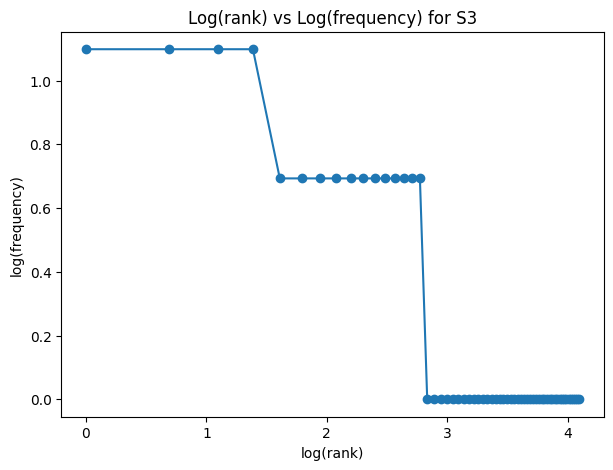


Top 5 bigrams of S1:
[(('.', 'the'), 5), (('.', 'i'), 5), (('i', 'have'), 3), (('have', 'tried'), 3), (('tried', 'several'), 3)]

Top 5 bigrams of S3:
[(('tried', 'several'), 3), (('several', 'times'), 3), (('crashes', 'opening'), 2), (('use', 'mobile'), 2), (('mobile', 'hotspot'), 2)]


In [11]:
from collections import Counter
from nltk.util import bigrams
from nltk.stem import PorterStemmer
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Create S1, S2, S3
# -----------------------------------

S1 = []
S2 = []
S3 = []

for ticket in df["Ticket_Text"]:

    result = process_ticket(ticket)

    # S1 = all tokens
    S1.extend(result["tokens"])

    # S2 = tokens without punctuation
    S2.extend([
        token for token in result["tokens"]
        if not is_punct(token)
    ])

    # S3 = final tokens
    S3.extend(result["final"])


# -----------------------------------
# S4 = S3 after Porter stemming
# -----------------------------------

porter = PorterStemmer()

S4 = [porter.stem(token) for token in S3]


# -----------------------------------
# Corpus statistics function
# -----------------------------------

def corpus_stats(tokens):
    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total > 0 else 0

    return total, unique, ttr


# -----------------------------------
# Statistics table
# -----------------------------------

stats = []

for name, corpus in [
    ("S1", S1),
    ("S2", S2),
    ("S3", S3),
    ("S4", S4)
]:

    total, unique, ttr = corpus_stats(corpus)

    stats.append([
        name,
        total,
        unique,
        round(ttr, 4)
    ])


stats_df = pd.DataFrame(
    stats,
    columns=["Corpus", "Total Tokens", "Unique Tokens", "TTR"]
)

print("Corpus Statistics:")
display(stats_df)


# -----------------------------------
# Top 10 words of S1
# -----------------------------------

print("\nTop 10 words of S1:")
print(Counter(S1).most_common(10))


# -----------------------------------
# Top 10 words of S3
# -----------------------------------

print("\nTop 10 words of S3:")
print(Counter(S3).most_common(10))


# -----------------------------------
# Log(rank) vs Log(frequency) for S3
# -----------------------------------

freq = Counter(S3)

frequencies = sorted(
    freq.values(),
    reverse=True
)

ranks = np.arange(1, len(frequencies) + 1)

plt.figure(figsize=(7, 5))

plt.plot(
    np.log(ranks),
    np.log(frequencies),
    marker='o'
)

plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Log(rank) vs Log(frequency) for S3")

plt.show()


# -----------------------------------
# Top 5 bigrams of S1
# -----------------------------------

S1_bigrams = Counter(bigrams(S1))

print("\nTop 5 bigrams of S1:")
print(S1_bigrams.most_common(5))


# -----------------------------------
# Top 5 bigrams of S3
# -----------------------------------

S3_bigrams = Counter(bigrams(S3))

print("\nTop 5 bigrams of S3:")
print(S3_bigrams.most_common(5))

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:* TTR changes because S1 contains all tokens including punctuation and stopwords, while S4 contains Porter-stemmed final tokens. Stemming combines different word forms into common stems, reducing the number of unique tokens. Therefore, the vocabulary size changes relative to the total number of tokens, causing the TTR to change.

Q6
(a) Why does TTR change from S1 to S4 in your dataset?
TTR changes because S1 contains all tokens, including punctuation and stopwords, while S4 contains final tokens after Porter stemming. Stemming combines different forms of words into common stems, which changes the number of unique tokens and therefore changes the TTR.

(b) Give one example where word_tokenize() and your tokenizer differ.
For example, word_tokenize() splits "isn't" into is and n't, whereas my tokenizer keeps "isn't" as a single token.

(c) Give one example where stemming produces an undesirable result.
Lancaster stemming changes "mobile" to "mobl". This is undesirable because mobl is not a meaningful English word.

(d) Give one example where POS-aware lemmatization preserves meaning better than stemming.
For example, "replied" can be lemmatized to "reply", which is a meaningful dictionary word, whereas stemming may produce "repli", which is not a proper English word.